# YOLOv5 Model Evaluation & Testing
## Comprehensive evaluation script for vehicle detection

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
import random
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("YOLOv5 MODEL EVALUATION PIPELINE")
print("=" * 80)

# ============================================================================
# 1. CONFIGURATION & SETUP
# ============================================================================

# Model paths
MODEL_PATH = "models/yolov5_1k.pt"
TEST_IMAGE_FOLDER = "vehicle_dataset/images/test/"
RESULTS_FOLDER = "results/"
TEST_LABELS_FOLDER = "vehicle_dataset/labels/test/"  # Optional: for metrics

# Confidence threshold
CONF_THRESHOLD = 0.45
IOU_THRESHOLD = 0.5

# Create results folder
os.makedirs(RESULTS_FOLDER, exist_ok=True)
os.makedirs(f"{RESULTS_FOLDER}annotated/", exist_ok=True)
os.makedirs(f"{RESULTS_FOLDER}detections/", exist_ok=True)

# Class mapping (from your config)
CLASS_NAMES = {0: "vehicle"}

print(f"[OK] Model path: {MODEL_PATH}")
print(f"[OK] Test image folder: {TEST_IMAGE_FOLDER}")
print(f"[OK] Results folder: {RESULTS_FOLDER}")
print(f"[OK] Confidence threshold: {CONF_THRESHOLD}")
print()

YOLOv5 MODEL EVALUATION PIPELINE
[OK] Model path: models/yolov5_1k.pt
[OK] Test image folder: vehicle_dataset/images/test/
[OK] Results folder: results/
[OK] Confidence threshold: 0.45



In [12]:
# ============================================================================
# 2. LOAD MODEL
# ============================================================================

try:
    model = YOLO(MODEL_PATH)
    print(f"[OK] Model loaded successfully: {MODEL_PATH}")
    print(f"[OK] Model type: {model.model.__class__.__name__}")
except Exception as e:
    print(f"[ERROR] Failed to load model: {e}")
    raise
print()

[OK] Model loaded successfully: models/yolov5_1k.pt
[OK] Model type: DetectionModel



In [13]:
# ============================================================================
# 3. COLLECT TEST IMAGES
# ============================================================================

def get_test_images(image_folder, extensions=('.jpg', '.jpeg', '.png')):
    """Collect all test images from folder"""
    test_images = []
    if os.path.exists(image_folder):
        for f in os.listdir(image_folder):
            if f.lower().endswith(extensions):
                test_images.append(os.path.join(image_folder, f))
    return sorted(test_images)

# Get all images
all_test_images = get_test_images(TEST_IMAGE_FOLDER)
print(f"[OK] Found {len(all_test_images)} test images")
if all_test_images:
    print("     Sample images:")
    for img in all_test_images[:5]:
        print(f"       - {os.path.basename(img)}")
print()

[OK] Found 150 test images
     Sample images:
       - MVI_20032_00180.jpg
       - MVI_20032_00200.jpg
       - MVI_20032_00340.jpg
       - MVI_20034_00380.jpg
       - MVI_20034_00740.jpg



In [14]:
# ============================================================================
# 4. RUN INFERENCE & COLLECT DETECTIONS
# ============================================================================

detections_all = []  # Store all detections
class_counts = defaultdict(int)

print("Running inference on all test images...")
print("-" * 80)

for idx, img_path in enumerate(all_test_images, 1):
    img_name = os.path.basename(img_path)
    
    try:
        # Run prediction
        results = model.predict(
            source=img_path, 
            conf=CONF_THRESHOLD, 
            iou=IOU_THRESHOLD,
            save=False, 
            verbose=False
        )
        
        result = results[0]
        num_detections = len(result.boxes)
        
        # Read original image for visualization
        img_original = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        # Get annotated image
        annotated_img = result.plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        # Save annotated image
        cv2.imwrite(
            os.path.join(RESULTS_FOLDER, "annotated", f"annotated_{img_name}"),
            annotated_img
        )
        
        # Extract detection details
        if num_detections > 0:
            boxes = result.boxes.xyxy.cpu().numpy()  # xyxy format
            confs = result.boxes.conf.cpu().numpy()
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            
            for box, conf, cls_id in zip(boxes, confs, class_ids):
                class_counts[CLASS_NAMES[cls_id]] += 1
                detections_all.append({
                    'image': img_name,
                    'class_id': cls_id,
                    'class_name': CLASS_NAMES[cls_id],
                    'confidence': conf,
                    'x1': box[0],
                    'y1': box[1],
                    'x2': box[2],
                    'y2': box[3],
                    'width': abs(box[2] - box[0]),
                    'height': abs(box[3] - box[1])
                })
        
        print(f"[{idx:2d}/{len(all_test_images)}] {img_name:30s} → {num_detections} detections")
        
    except Exception as e:
        print(f"[{idx:2d}/{len(all_test_images)}] {img_name:30s} → ERROR: {e}")

print("-" * 80)
print(f"✓ Inference complete!")
print()

Running inference on all test images...
--------------------------------------------------------------------------------
[ 1/150] MVI_20032_00180.jpg            → 5 detections
[ 2/150] MVI_20032_00200.jpg            → 5 detections
[ 3/150] MVI_20032_00340.jpg            → 3 detections
[ 4/150] MVI_20034_00380.jpg            → 11 detections
[ 5/150] MVI_20034_00740.jpg            → 15 detections
[ 6/150] MVI_20035_00140.jpg            → 15 detections
[ 7/150] MVI_20052_00420.jpg            → 13 detections
[ 8/150] MVI_20052_00480.jpg            → 9 detections
[ 9/150] MVI_20052_00580.jpg            → 8 detections
[10/150] MVI_20062_00040.jpg            → 7 detections
[11/150] MVI_20062_00060.jpg            → 7 detections
[12/150] MVI_20062_00240.jpg            → 5 detections
[13/150] MVI_20062_00580.jpg            → 5 detections
[14/150] MVI_20064_00640.jpg            → 16 detections
[15/150] MVI_20064_00780.jpg            → 19 detections
[16/150] MVI_39031_00580.jpg            → 5 dete

In [15]:
# ============================================================================
# 5. DISPLAY DETECTED BOXES & STATISTICS
# ============================================================================

print("=" * 80)
print("DETECTION SUMMARY")
print("=" * 80)

# Create detections DataFrame
if detections_all:
    df_detections = pd.DataFrame(detections_all)
    print(f"\nTotal detections: {len(df_detections)}")
    print(f"Total images processed: {len(all_test_images)}")
    print(f"Average detections per image: {len(df_detections) / len(all_test_images):.2f}")
    
    print("\n" + "=" * 80)
    print("DETECTIONS BY CLASS")
    print("=" * 80)
    for class_name, count in sorted(class_counts.items()):
        print(f"  {class_name:15s}: {count:4d} detections")
    
    print("\n" + "=" * 80)
    print("SAMPLE OF DETECTED BOXES (First 20)")
    print("=" * 80)
    display_cols = ['image', 'class_name', 'confidence', 'x1', 'y1', 'x2', 'y2']
    print(df_detections[display_cols].head(20).to_string())
    
    # Save detections to CSV
    df_detections.to_csv(
        os.path.join(RESULTS_FOLDER, "detections_log.csv"), 
        index=False
    )
    print(f"\n[OK] Detections saved to: {RESULTS_FOLDER}detections_log.csv")
else:
    print("\n[WARNING] No detections found in any image!")

print()

DETECTION SUMMARY

Total detections: 1400
Total images processed: 150
Average detections per image: 9.33

DETECTIONS BY CLASS
  vehicle        : 1400 detections

SAMPLE OF DETECTED BOXES (First 20)
                  image class_name  confidence          x1          y1          x2          y2
0   MVI_20032_00180.jpg    vehicle    0.902897  287.455627  149.350250  343.727875  197.910828
1   MVI_20032_00180.jpg    vehicle    0.843875  459.400879   75.237747  488.831787  104.119690
2   MVI_20032_00180.jpg    vehicle    0.823062  399.441467   84.265846  430.541382  115.159950
3   MVI_20032_00180.jpg    vehicle    0.819241  593.367310   56.084885  618.000488   79.332779
4   MVI_20032_00180.jpg    vehicle    0.786208  563.753357   50.671234  587.337524   70.997620
5   MVI_20032_00200.jpg    vehicle    0.893388  291.440918  147.941299  342.935577  196.719482
6   MVI_20032_00200.jpg    vehicle    0.865364  390.352600   91.337646  424.403809  122.123047
7   MVI_20032_00200.jpg    vehicle    0.86

VISUALIZING ANNOTATED IMAGES


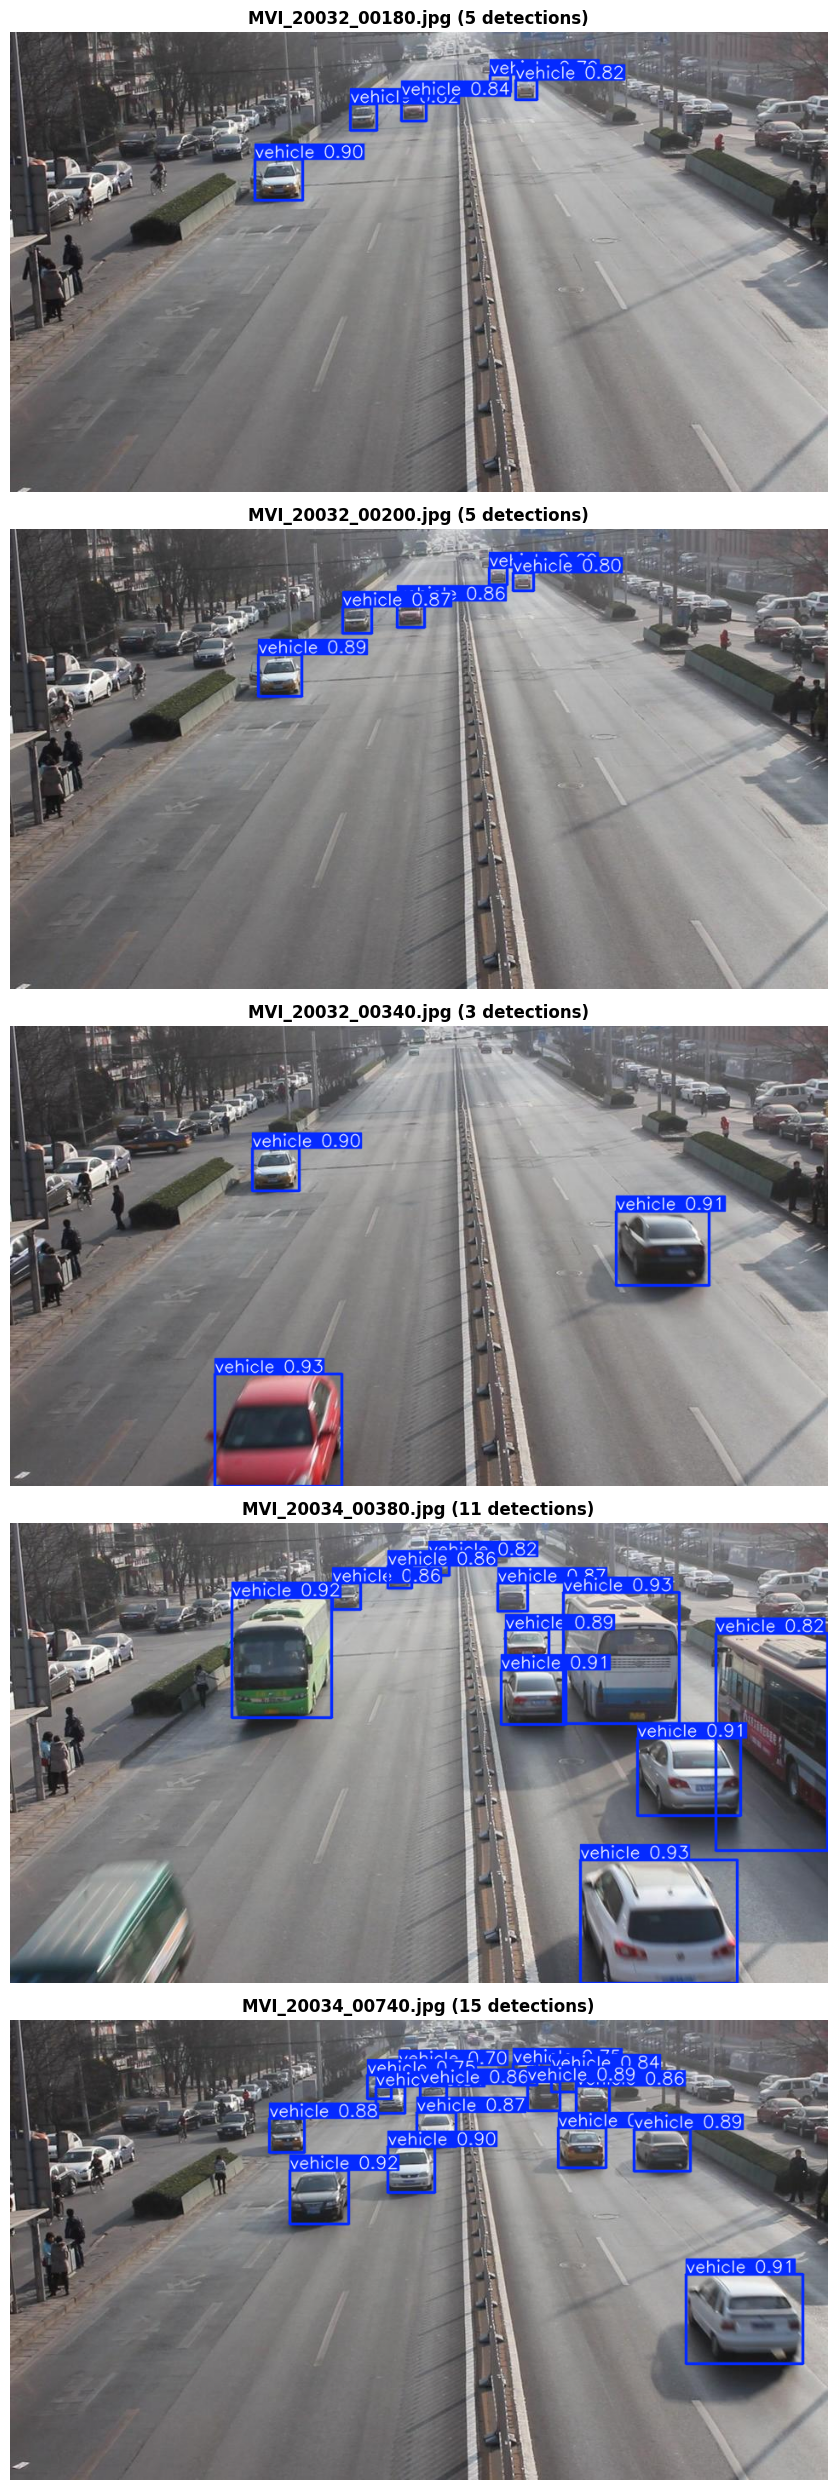

[OK] Sample predictions saved to: results/sample_predictions.png



In [16]:
# ============================================================================
# 6. VISUALIZE ANNOTATED RESULTS
# ============================================================================

print("=" * 80)
print("VISUALIZING ANNOTATED IMAGES")
print("=" * 80)

num_to_show = min(5, len(all_test_images))
fig, axes = plt.subplots(num_to_show, 1, figsize=(14, 5 * num_to_show))

if num_to_show == 1:
    axes = [axes]

for idx, img_path in enumerate(all_test_images[:num_to_show]):
    img_name = os.path.basename(img_path)
    
    # Run inference to get annotated version
    results = model.predict(img_path, conf=CONF_THRESHOLD, save=False, verbose=False)
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Get detection count for this image
    num_dets = len(results[0].boxes)
    
    axes[idx].imshow(annotated_img_rgb)
    axes[idx].set_title(f"{img_name} ({num_dets} detections)", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, "sample_predictions.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"[OK] Sample predictions saved to: {RESULTS_FOLDER}sample_predictions.png")
print()

CONFIDENCE SCORE ANALYSIS
  Mean confidence:   0.8606
  Median confidence: 0.8854
  Min confidence:    0.4506
  Max confidence:    0.9691
  Std deviation:     0.0837


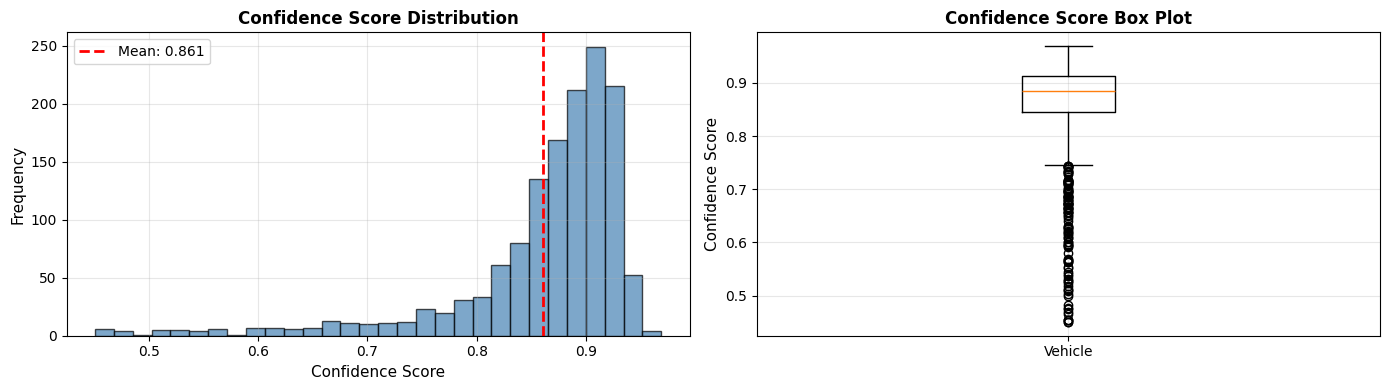


[OK] Confidence analysis saved to: results/confidence_analysis.png



In [17]:
# ============================================================================
# 7. CONFIDENCE SCORE ANALYSIS
# ============================================================================

if detections_all:
    print("=" * 80)
    print("CONFIDENCE SCORE ANALYSIS")
    print("=" * 80)
    
    confidences = df_detections['confidence'].values
    
    print(f"  Mean confidence:   {confidences.mean():.4f}")
    print(f"  Median confidence: {np.median(confidences):.4f}")
    print(f"  Min confidence:    {confidences.min():.4f}")
    print(f"  Max confidence:    {confidences.max():.4f}")
    print(f"  Std deviation:     {confidences.std():.4f}")
    
    # Confidence distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram
    axes[0].hist(confidences, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(confidences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {confidences.mean():.3f}')
    axes[0].set_xlabel('Confidence Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Confidence Score Distribution', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot([confidences], labels=['Vehicle'])
    axes[1].set_ylabel('Confidence Score', fontsize=11)
    axes[1].set_title('Confidence Score Box Plot', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, "confidence_analysis.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n[OK] Confidence analysis saved to: {RESULTS_FOLDER}confidence_analysis.png")
else:
    print("[WARNING] No detections to analyze confidence scores")

print()

BOUNDING BOX SIZE ANALYSIS
  Mean box area:     8129 pixels²
  Median box area:   3662 pixels²
  Min box area:      278 pixels²
  Max box area:      153999 pixels²


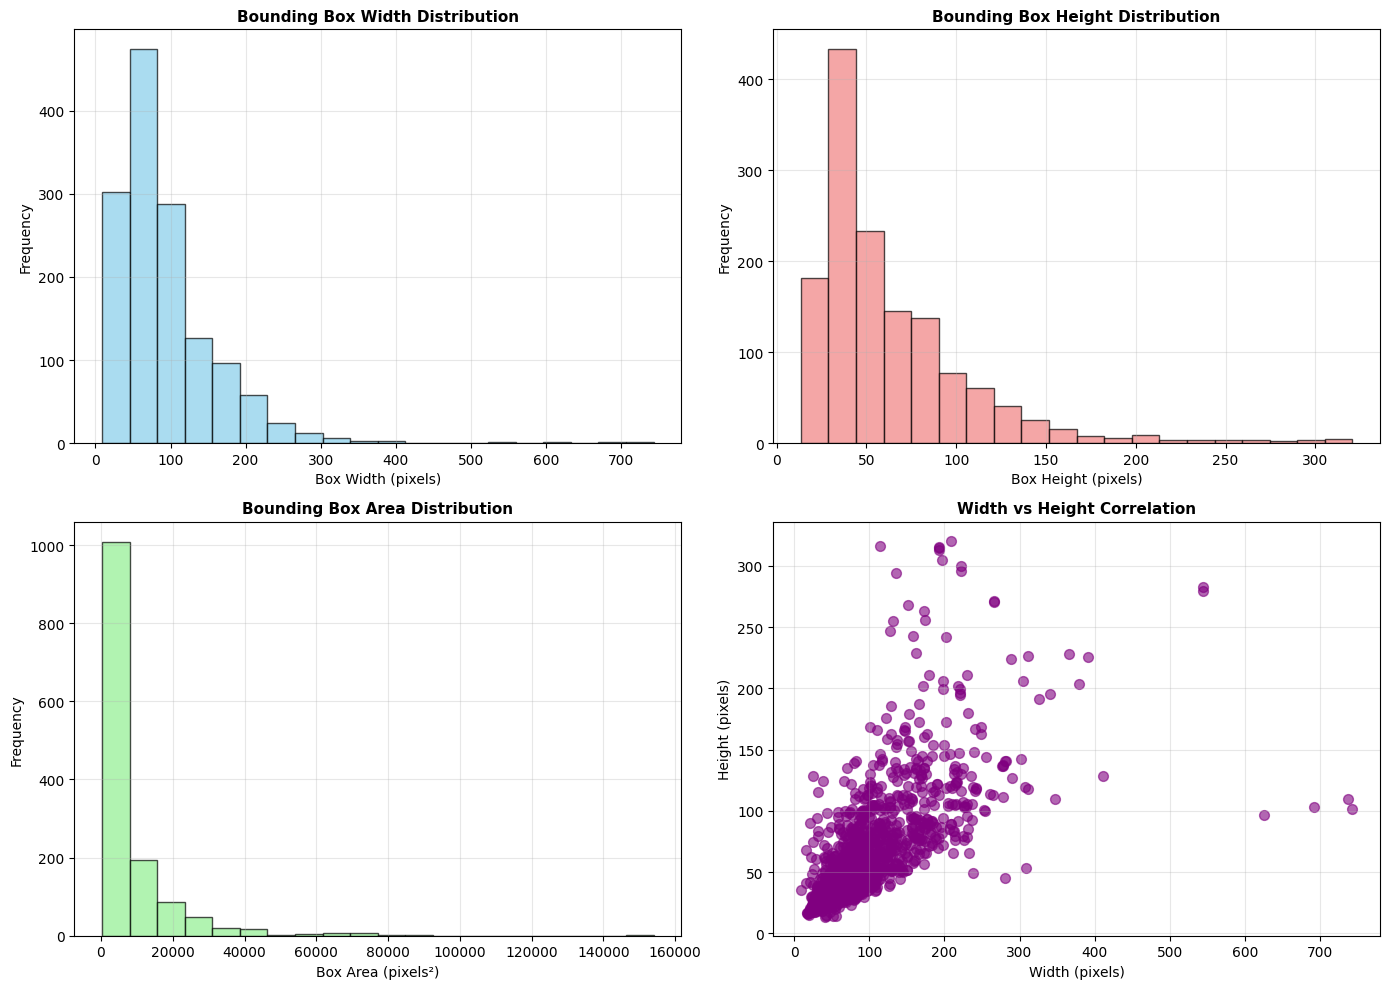


[OK] Bounding box analysis saved to: results/bbox_analysis.png



In [18]:
# ============================================================================
# 8. BOUNDING BOX ANALYSIS
# ============================================================================

if detections_all:
    print("=" * 80)
    print("BOUNDING BOX SIZE ANALYSIS")
    print("=" * 80)
    
    areas = df_detections['width'] * df_detections['height']
    
    print(f"  Mean box area:     {areas.mean():.0f} pixels²")
    print(f"  Median box area:   {np.median(areas):.0f} pixels²")
    print(f"  Min box area:      {areas.min():.0f} pixels²")
    print(f"  Max box area:      {areas.max():.0f} pixels²")
    
    # Size analysis visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Width distribution
    axes[0, 0].hist(df_detections['width'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].set_xlabel('Box Width (pixels)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Bounding Box Width Distribution', fontsize=11, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Height distribution
    axes[0, 1].hist(df_detections['height'], bins=20, edgecolor='black', alpha=0.7, color='lightcoral')
    axes[0, 1].set_xlabel('Box Height (pixels)', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].set_title('Bounding Box Height Distribution', fontsize=11, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Area distribution
    axes[1, 0].hist(areas, bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1, 0].set_xlabel('Box Area (pixels²)', fontsize=10)
    axes[1, 0].set_ylabel('Frequency', fontsize=10)
    axes[1, 0].set_title('Bounding Box Area Distribution', fontsize=11, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)
    
    # Width vs Height scatter
    axes[1, 1].scatter(df_detections['width'], df_detections['height'], alpha=0.6, s=50, color='purple')
    axes[1, 1].set_xlabel('Width (pixels)', fontsize=10)
    axes[1, 1].set_ylabel('Height (pixels)', fontsize=10)
    axes[1, 1].set_title('Width vs Height Correlation', fontsize=11, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, "bbox_analysis.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n[OK] Bounding box analysis saved to: {RESULTS_FOLDER}bbox_analysis.png")

print()

In [19]:
# ============================================================================
# 9. LOW CONFIDENCE DETECTIONS (POTENTIAL MISDETECTIONS)
# ============================================================================

if detections_all:
    print("=" * 80)
    print("LOW CONFIDENCE DETECTIONS (< 0.6)")
    print("=" * 80)
    
    low_conf_threshold = 0.6
    low_conf_detections = df_detections[df_detections['confidence'] < low_conf_threshold]
    
    if len(low_conf_detections) > 0:
        print(f"\nFound {len(low_conf_detections)} detections with confidence < {low_conf_threshold}")
        print("\nTop 15 lowest confidence detections:")
        print("-" * 80)
        
        low_det_display = low_conf_detections[['image', 'class_name', 'confidence']].sort_values('confidence')
        for idx, row in low_det_display.head(15).iterrows():
            print(f"  {row['image']:30s} - {row['class_name']:10s} - Confidence: {row['confidence']:.4f}")
        
        low_conf_detections.to_csv(
            os.path.join(RESULTS_FOLDER, "low_confidence_detections.csv"),
            index=False
        )
        print(f"\n[OK] Low confidence detections saved to: {RESULTS_FOLDER}low_confidence_detections.csv")
    else:
        print(f"\n[OK] All detections have confidence >= {low_conf_threshold}")

print()

LOW CONFIDENCE DETECTIONS (< 0.6)

Found 37 detections with confidence < 0.6

Top 15 lowest confidence detections:
--------------------------------------------------------------------------------
  MVI_39031_01320.jpg            - vehicle    - Confidence: 0.4506
  MVI_20064_00780.jpg            - vehicle    - Confidence: 0.4507
  MVI_40244_00520.jpg            - vehicle    - Confidence: 0.4537
  MVI_39501_00280.jpg            - vehicle    - Confidence: 0.4540
  MVI_41063_01340.jpg            - vehicle    - Confidence: 0.4550
  MVI_40864_01240.jpg            - vehicle    - Confidence: 0.4660
  MVI_40131_00240.jpg            - vehicle    - Confidence: 0.4696
  MVI_39031_01120.jpg            - vehicle    - Confidence: 0.4741
  MVI_40191_02180.jpg            - vehicle    - Confidence: 0.4775
  MVI_40201_00740.jpg            - vehicle    - Confidence: 0.4828
  MVI_20064_00780.jpg            - vehicle    - Confidence: 0.4993
  MVI_40192_00500.jpg            - vehicle    - Confidence: 0.5028


In [20]:
# ============================================================================
# 10. FINAL SUMMARY REPORT
# ============================================================================

print("=" * 80)
print("FINAL EVALUATION SUMMARY REPORT")
print("=" * 80)

summary_report = f"""
[STATS] DATASET STATISTICS
{'─' * 76}
  Total test images:              {len(all_test_images)}
  Total detections:               {len(detections_all) if detections_all else 0}
  Average detections per image:   {len(detections_all) / len(all_test_images):.2f}

[DETECTIONS] DETECTION BREAKDOWN BY CLASS
{'─' * 76}
"""

for class_name in sorted(class_counts.keys()):
    count = class_counts[class_name]
    percentage = (count / len(detections_all) * 100) if detections_all else 0
    summary_report += f"  {class_name:15s}: {count:4d} detections ({percentage:5.1f}%)\n"

if detections_all:
    summary_report += f"""
[METRICS] CONFIDENCE METRICS
{'─' * 76}
  Minimum confidence:             {df_detections['confidence'].min():.4f}
  Mean confidence:                {df_detections['confidence'].mean():.4f}
  Median confidence:              {df_detections['confidence'].median():.4f}
  Maximum confidence:             {df_detections['confidence'].max():.4f}
  Std deviation:                  {df_detections['confidence'].std():.4f}

[DIMENSIONS] BOUNDING BOX DIMENSIONS
{'─' * 76}
  Average width:                  {df_detections['width'].mean():.1f} pixels
  Average height:                 {df_detections['height'].mean():.1f} pixels
  Average area:                   {(df_detections['width'] * df_detections['height']).mean():.0f} pixels²

[CONFIG] MODEL CONFIGURATION
{'─' * 76}
  Model path:                     {MODEL_PATH}
  Confidence threshold:           {CONF_THRESHOLD}
  IoU threshold:                  {IOU_THRESHOLD}

[FILES] OUTPUT FILES
{'─' * 76}
  [OK] Annotated images:          {RESULTS_FOLDER}annotated/
  [OK] Detections log (CSV):      {RESULTS_FOLDER}detections_log.csv
  [OK] Sample predictions:        {RESULTS_FOLDER}sample_predictions.png
  [OK] Confidence analysis:       {RESULTS_FOLDER}confidence_analysis.png
  [OK] Bounding box analysis:     {RESULTS_FOLDER}bbox_analysis.png
"""

summary_report += f"{'─' * 76}\n"

print(summary_report)

# Save report to file
report_path = os.path.join(RESULTS_FOLDER, "evaluation_report.txt")
with open(report_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("YOLOV5 MODEL EVALUATION REPORT\n")
    f.write("=" * 80 + "\n\n")
    f.write(summary_report)

print(f"[OK] Full report saved to: {report_path}")
print("=" * 80)

FINAL EVALUATION SUMMARY REPORT

[STATS] DATASET STATISTICS
────────────────────────────────────────────────────────────────────────────
  Total test images:              150
  Total detections:               1400
  Average detections per image:   9.33

[DETECTIONS] DETECTION BREAKDOWN BY CLASS
────────────────────────────────────────────────────────────────────────────
  vehicle        : 1400 detections (100.0%)

[METRICS] CONFIDENCE METRICS
────────────────────────────────────────────────────────────────────────────
  Minimum confidence:             0.4506
  Mean confidence:                0.8606
  Median confidence:              0.8854
  Maximum confidence:             0.9691
  Std deviation:                  0.0838

[DIMENSIONS] BOUNDING BOX DIMENSIONS
────────────────────────────────────────────────────────────────────────────
  Average width:                  93.8 pixels
  Average height:                 64.2 pixels
  Average area:                   8129 pixels²

[CONFIG] MODEL C

UnicodeEncodeError: 'charmap' codec can't encode characters in position 30-105: character maps to <undefined>

In [ ]:
# ============================================================================
# 11. OPTIONAL: GROUND TRUTH COMPARISON (If labels available)
# ============================================================================

print("\n" + "=" * 80)
print("GROUND TRUTH LABEL CHECKING")
print("=" * 80)

# Check if labels folder exists
if os.path.exists(TEST_LABELS_FOLDER):
    print(f"[OK] Test labels folder found: {TEST_LABELS_FOLDER}")
    
    label_files = [f for f in os.listdir(TEST_LABELS_FOLDER) if f.endswith('.txt')]
    print(f"[OK] Found {len(label_files)} label files")
    
    # Load ground truth counts
    total_gt_objects = 0
    gt_by_class = defaultdict(int)
    
    for label_file in label_files[:5]:  # Sample check
        label_path = os.path.join(TEST_LABELS_FOLDER, label_file)
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
                total_gt_objects += len(lines)
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        class_name = CLASS_NAMES.get(class_id, f"class_{class_id}")
                        gt_by_class[class_name] += 1
        except:
            pass
    
    print(f"\nGround Truth Statistics (sampled):")
    print(f"  Total objects in sample: {total_gt_objects}")
    for cls_name in sorted(gt_by_class.keys()):
        print(f"  {cls_name}: {gt_by_class[cls_name]}")
    
    if detections_all and total_gt_objects > 0:
        pred_count = len(detections_all)
        print(f"\n  Predicted detections: {pred_count}")
        print(f"  Ground truth objects: {total_gt_objects}")
        print(f"  Ratio (Pred/GT):     {pred_count / total_gt_objects:.2f}")
else:
    print(f"[WARNING] Labels folder not found: {TEST_LABELS_FOLDER}")
    print("  Skipping ground truth comparison. To enable metrics computation,")
    print("  place label files (.txt) in the test_labels folder with YOLO format.")

print("\n" + "=" * 80)
print("[OK] EVALUATION COMPLETE!")
print("=" * 80)

In [ ]:
# ============================================================================
# 12. UTILITY: TEST SINGLE IMAGE OR CUSTOM BATCH
# ============================================================================

def test_single_image(image_path, conf=CONF_THRESHOLD):
    """Test a single image and display results"""
    if not os.path.exists(image_path):
        print(f"[ERROR] Image not found: {image_path}")
        return
    
    print(f"\nTesting: {image_path}")
    print("-" * 80)
    
    results = model.predict(image_path, conf=conf, verbose=False)
    result = results[0]
    
    # Display image with annotations
    fig, ax = plt.subplots(figsize=(12, 8))
    annotated = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    ax.set_title(f"Detections for {os.path.basename(image_path)}", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print detection details
    boxes = result.boxes
    if len(boxes) > 0:
        print(f"\n[OK] Found {len(boxes)} detections:")
        print("\n  Image    | Class       | Conf   | X1      | Y1      | X2      | Y2")
        print("  " + "-" * 80)
        for idx, (box, conf, cls_id) in enumerate(zip(boxes.xyxy, boxes.conf, boxes.cls)):
            box_np = box.cpu().numpy()
            conf_val = conf.cpu().numpy()
            cls_val = int(cls_id.cpu().numpy())
            print(f"  {idx+1:2d}     | {CLASS_NAMES[cls_val]:11s} | {conf_val:.4f} | {box_np[0]:7.1f} | {box_np[1]:7.1f} | {box_np[2]:7.1f} | {box_np[3]:7.1f}")
    else:
        print("\n[WARNING] No detections found")

# Example usage:
# test_single_image("test/image/test.jpg")
print("\n" + "=" * 80)
print("UTILITY FUNCTION AVAILABLE:")
print("=" * 80)
print("Use: test_single_image(<image_path>, conf=0.45)")
print("Example: test_single_image('test/image/test.jpg')")
print("=" * 80)